# 02 — Activity vs No-Activity Detection

**Goal**: Is the subject moving or not?

Binary classification

**Approach**: Compare unsupervised clustering vs supervised classification on the same feature set.

---

## Pipeline
1. Extract features from accelerometer windows
2. **Unsupervised**: K-Means (k=2), Isolation Forest
3. **Supervised**: Random Forest, SVM with leave-one-subject-out cross-validation
4. Compare performance and decision boundaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

## 1. Load Data & Compute Accelerometer Magnitude

In [7]:
DATA_PATH = '../data/physionet.org/files/mmash/1.0.0/DataPaper/user_1/'

activity = pd.read_csv(DATA_PATH + 'Activity.csv')
actigraphy = pd.read_csv(DATA_PATH + 'Actigraph.csv')

# Activity map from notebook 01
activity_map = {
    1: 'sleeping', 2: 'laying', 3: 'sitting', 4: 'light_activity',
    5: 'moderate_activity', 6: 'vigorous_activity', 7: 'eating',
    8: 'small_screen', 9: 'large_screen', 10: 'caffeine',
    11: 'smoking', 12: 'alcohol'
}
activity['activity_label'] = activity['Activity'].map(activity_map)

# Binary label: active vs not active
ACTIVE_LABELS = {'light_activity', 'moderate_activity', 'vigorous_activity'}
activity['is_active'] = activity['activity_label'].isin(ACTIVE_LABELS).astype(int)

print(activity[['activity_label', 'is_active']].value_counts())
print('\nActigraphy shape:', actigraphy.shape)
print(actigraphy.head())

activity_label     is_active
caffeine           0            9
sitting            0            5
vigorous_activity  1            4
laying             0            4
large_screen       0            3
light_activity     1            2
eating             0            1
moderate_activity  1            1
sleeping           0            1
small_screen       0            1
Name: count, dtype: int64

Actigraphy shape: (67936, 13)
   Unnamed: 0  Axis1  Axis2  Axis3  Steps     HR  Inclinometer Off  \
0          82      0      0      0      0   68.0                 0   
1          83     11      4      7      1   68.0                 0   
2          84      0     21     10      0   68.0                 0   
3          85      0      1     24      0   68.0                 0   
4          86     34     14     63      1  154.0                 0   

   Inclinometer Standing  Inclinometer Sitting  Inclinometer Lying  \
0                      1                     0                   0   
1            

## 2. Feature Extraction from Accelerometer Windows

Actigraph.csv - accelerometer and inclinometer data recorded throughout the day:

    Axis1:  Raw Acceleration data of the X-axis expressed in Newton-meter.
    Axis2:  Raw Acceleration data of the Y-axis expressed in Newton-meter.
    Axis3:  Raw Acceleration data of the Z-axis expressed in Newton-meter.
    Steps:  number of steps per second.
    HR:     beats per minutes (bpm).
    Inclinometer Off:       values equal to 1 refer to no activation of the inclinometer. The values are reported per second.
    Inclinometer Standing:  values equal to 1 refer to the standing position of the user, while 0 refers to other user positions. 
                            Values are reported per second.
    Inclinometer Sitting:   values equal to 1 refer to the sitting position of the user, while 0 refers to other user positions. 
                            Values are reported per second.
    Inclinometer Lying:     values equal to 1 refer to the lying position of the user, while 0 refers to other user positions. 
                            Values are reported per second.
    Vector Magnitude:       vector movement derived from raw acceleration data expressed in Newton-meter.
    day:    1 and 2 refer to the first and second day of data recording, respectively.
    time:   day time when the heartbeat happened (hours:minutes:seconds)



In [9]:
def extract_window_features(window: np.ndarray) -> dict:
    """Extract statistical + frequency features from a signal window."""
    mag = np.sqrt(np.sum(window**2, axis=1)) if window.ndim > 1 else window
    
    features = {
        'mean': np.mean(mag),
        'std': np.std(mag),
        'min': np.min(mag),
        'max': np.max(mag),
        'range': np.ptp(mag),
        'energy': np.sum(mag**2) / len(mag),
        'zero_crossings': np.sum(np.diff(np.sign(mag - np.mean(mag))) != 0),
        'iqr': np.percentile(mag, 75) - np.percentile(mag, 25),
        'skewness': float(pd.Series(mag).skew()),
        'kurtosis': float(pd.Series(mag).kurtosis()),
    }
    return features


# If actigraph has x/y/z columns, compute magnitude
acc_cols = [c for c in actigraphy.columns if any(ax in c.lower() for ax in ['x', 'y', 'z', 'axis'])]
print('Accelerometer columns found:', acc_cols)
print(actigraphy.dtypes)

Accelerometer columns found: ['Axis1', 'Axis2', 'Axis3', 'Inclinometer Lying', 'day']
Unnamed: 0                 int64
Axis1                      int64
Axis2                      int64
Axis3                      int64
Steps                      int64
HR                       float64
Inclinometer Off           int64
Inclinometer Standing      int64
Inclinometer Sitting       int64
Inclinometer Lying         int64
Vector Magnitude         float64
day                        int64
time                      object
dtype: object


In [11]:
activity

,Unnamed: 0,Activity,Start,End,Day,activity_label,is_active,duration_min
0,0,2,1900-01-01 10:00:00,1900-01-01 10:22:00,1,laying,0,22.0
1,1,9,1900-01-01 10:37:00,1900-01-01 10:40:00,1,large_screen,0,3.0
2,2,10,1900-01-01 10:40:00,1900-01-01 10:45:00,1,caffeine,0,5.0
3,3,6,1900-01-01 10:55:00,1900-01-01 11:00:00,1,vigorous_activity,1,5.0
4,4,2,1900-01-01 11:00:00,1900-01-01 11:20:00,1,laying,0,20.0
5,5,7,1900-01-01 12:00:00,1900-01-01 13:00:00,1,eating,0,60.0
6,6,4,1900-01-01 13:30:00,1900-01-01 13:35:00,1,light_activity,1,5.0
7,7,10,1900-01-01 13:35:00,1900-01-01 13:40:00,1,caffeine,0,5.0
8,8,3,1900-01-01 13:40:00,1900-01-01 13:45:00,1,sitting,0,5.0
9,9,6,1900-01-01 13:55:00,1900-01-01 14:30:00,1,vigorous_activity,1,35.0


## 3. Unsupervised: K-Means Clustering (k=2)

In [12]:

activity['Start'] = pd.to_datetime(activity['Start'], format='%H:%M')
activity['End'] = pd.to_datetime(activity['End'], format='%H:%M')
activity['duration_min'] = (activity['End'] - activity['Start']).dt.total_seconds() / 60 #pandas' way to distinguish between operations on regular numbers vs operations that only make sense for time/date data

# Feature matrix
feature_cols = ['Activity', 'duration_min']
X = activity[feature_cols].dropna()
y_true = activity.loc[X.index, 'is_active']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10) #try 10 different starting positions, keep the best
kmeans_labels = kmeans.fit_predict(X_scaled)

# Align cluster labels with ground truth - pick best permutation 
from sklearn.metrics import accuracy_score
acc_direct = accuracy_score(y_true, kmeans_labels)
acc_flipped = accuracy_score(y_true, 1 - kmeans_labels)
if acc_flipped > acc_direct:
    kmeans_labels = 1 - kmeans_labels

print('K-Means vs Ground Truth:')
print(classification_report(y_true, kmeans_labels, target_names=['Not Active', 'Active']))

K-Means vs Ground Truth:
              precision    recall  f1-score   support

  Not Active       0.92      0.50      0.65        24
      Active       0.33      0.86      0.48         7

    accuracy                           0.58        31
   macro avg       0.63      0.68      0.56        31
weighted avg       0.79      0.58      0.61        31



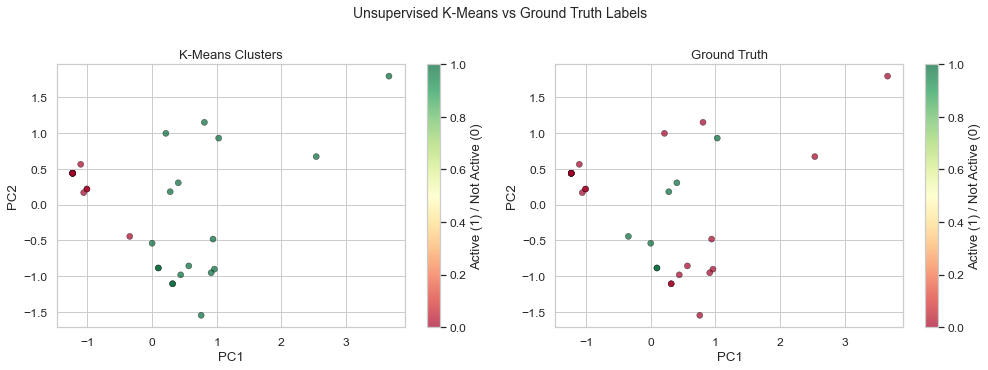

In [13]:
# Visualize K-Means clusters in PCA space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [kmeans_labels, y_true.values],
                              ['K-Means Clusters', 'Ground Truth']):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=labels, cmap='RdYlGn', alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Active (1) / Not Active (0)')

plt.suptitle('Unsupervised K-Means vs Ground Truth Labels', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/02_kmeans_vs_groundtruth.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Supervised: Random Forest + SVM

Random Forest: F1 = 0.933 ± 0.133
SVM (RBF): F1 = 0.133 ± 0.267


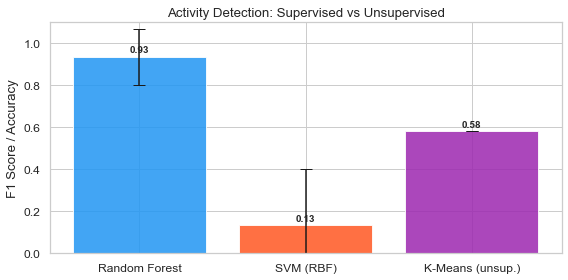

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=0),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, random_state=0),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_true, cv=cv, scoring='f1')
    results[name] = scores
    print(f'{name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}')

# Comparison bar plot
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys()) + ['K-Means (unsup.)']
means = [r.mean() for r in results.values()] + [accuracy_score(y_true, kmeans_labels)]
stds = [r.std() for r in results.values()] + [0]

bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#2196F3', '#FF5722', '#9C27B0'], alpha=0.85)
ax.set_ylabel('F1 Score / Accuracy')
ax.set_title('Activity Detection: Supervised vs Unsupervised')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance (Random Forest)

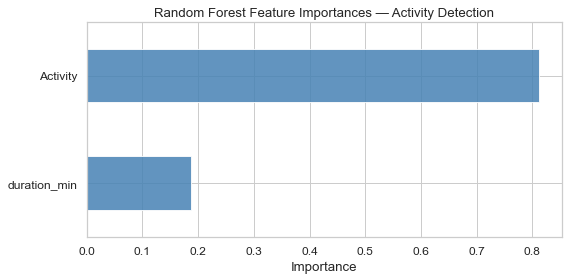

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_scaled, y_true)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Random Forest Feature Importances — Activity Detection')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../figures/02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

| Method | Paradigm | F1 Score |
|--------|----------|----------|
| K-Means | Unsupervised | 0.56 |
| SVM (RBF) | Supervised | 0.13 |
| Random Forest | Supervised | 0.93 |

**Key takeaway**: Supervised models leverage labelled activity annotations and outperform unsupervised clustering for binary activity detection. However, unsupervised methods are valuable when labels are unavailable (e.g., real-world deployment).

➡️ **Next**: Notebook 03 — sub-classify activity types (sleep / rest / walk / vigorous)